# 05. Monthly Sentinel-2 Composites for the CNN

The tabular analysis (Notebook 04) showed that weekly Sentinel-2 summary statistics
(NDVI/NDMI means, percentiles and trends) add no detectable predictive value once
weather and historical context are known. Those features compress each 5 km cell into
a few numbers.

This notebook prepares the input for a different test: can a convolutional neural
network extract more information about **vegetation state** from the full image?

### Design

- **One cloud-free composite per month**, April–September, 2017–2025 (54 composites).
- Each weekly observation uses the composite of the **previous complete month**
  (e.g. weeks starting in August use the July composite). The composite always ends
  before the reference Monday, so no future information is used. Images are at most
  about five weeks old.
- Source: `COPERNICUS/S2_SR_HARMONIZED` (surface reflectance, as in Notebook 03).
  Clouds are masked with `COPERNICUS/S2_CLOUD_PROBABILITY`; the composite is the
  per-pixel median.
- Bands: **B4 (red), B8 (near infrared) and B11 (short-wave infrared)**, the bands
  that respond to vegetation greenness and moisture (NDVI and NDMI).
- Export: national rasters in **EPSG:3763 at 40 m**, aligned with the 5 km grid,
  so every cell maps to exactly **125 × 125 pixels**.

In [2]:
from pathlib import Path

import ee
import geopandas as gpd
import numpy as np
import pandas as pd

ee.Authenticate(auth_mode="localhost")
ee.Initialize(project="wildfireproject-506722")

PROCESSED_DIR = Path("../data/processed")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\ee\data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(
*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [3]:
grid = gpd.read_parquet("../data/interim/grid_5km_portugal.parquet")

districts = gpd.read_file(
    "../data/raw/CAOP_Continente_2025-gpkg/Continente_CAOP2025.gpkg",
    layer="cont_distritos"
)
portugal = districts.geometry.union_all()

assert grid.crs.to_epsg() == 3763 and districts.crs.to_epsg() == 3763

# Grid bounds are aligned with the 5 km cell edges.
min_x, min_y, max_x, max_y = grid.total_bounds

PIXEL_SIZE = 40
CELL_PIXELS = 5000 // PIXEL_SIZE

width = int(round((max_x - min_x) / PIXEL_SIZE))
height = int(round((max_y - min_y) / PIXEL_SIZE))

print("Raster size (px):", width, "x", height)
print("Pixels per cell:", CELL_PIXELS)

# Simplified Portugal polygon in WGS84, only for filtering and statistics.
portugal_ee = ee.Geometry(
    gpd.GeoSeries([portugal.simplify(500)], crs=districts.crs)
    .to_crs("EPSG:4326")
    .iloc[0]
    .__geo_interface__
)

Raster size (px): 7125 x 14500
Pixels per cell: 125


## 1. Monthly composites

For each month, all Sentinel-2 surface-reflectance images over Portugal are cloud-masked
with two complementary masks: the matching cloud-probability image (pixels with
probability ≥ 40% are removed) and the Scene Classification Layer (SCL), which removes
cloud shadows, medium- and high-probability clouds and thin cirrus. A pixel is kept only
if both masks consider it clear. The per-pixel median of the remaining observations is
then taken.

In [4]:
COLLECTION = "COPERNICUS/S2_SR_HARMONIZED"
BANDS = ["B4", "B8", "B11"]
CLOUD_THRESHOLD = 40
YEARS = range(2017, 2026)
MONTHS = range(4, 10)   # April–September: previous month of every May–October week
LOOKBACK_DAYS = 60


def masked_collection(start, end):
    """Cloud-masked Sentinel-2 images (B4, B8, B11) between start and end."""
    s2 = (
        ee.ImageCollection(COLLECTION)
        .filterBounds(portugal_ee)
        .filterDate(start, end)
    )
    clouds = (
        ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
        .filterBounds(portugal_ee)
        .filterDate(start, end)
    )

    joined = ee.ImageCollection(
        ee.Join.saveFirst("cloud_prob").apply(
            primary=s2,
            secondary=clouds,
            condition=ee.Filter.equals(
                leftField="system:index", rightField="system:index"
            ),
        )
    )

    def mask_clouds(image):
        probability = ee.Image(image.get("cloud_prob")).select("probability")
        scl = image.select("SCL")

        # SCL classes: 3 = cloud shadow, 8/9 = cloud (medium/high), 10 = thin cirrus
        flagged_by_scl = scl.eq(3).Or(scl.eq(8)).Or(scl.eq(9)).Or(scl.eq(10))

        clear = probability.lt(CLOUD_THRESHOLD).And(flagged_by_scl.Not())
        return image.updateMask(clear).select(BANDS)

    return joined.map(mask_clouds), s2.size()


def monthly_composite(year, month):
    """Per-pixel median of all cloud-free observations in the month."""
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")
    masked, n_images = masked_collection(start, end)
    return masked.median(), masked, n_images


def filled_composite(year, month):
    """
    Monthly median composite. Pixels with no cloud-free observation in the month
    are filled with the MOST RECENT cloud-free observation from the previous
    LOOKBACK_DAYS days (older information, so no leakage).
    """
    composite, masked, n_images = monthly_composite(year, month)

    month_start = ee.Date.fromYMD(year, month, 1)
    history, _ = masked_collection(
        month_start.advance(-LOOKBACK_DAYS, "day"), month_start
    )

    # mosaic() puts the last image on top: sorting by date makes the most
    # recent cloud-free pixel win wherever several are available.
    latest_clear = history.sort("system:time_start").mosaic()

    return composite.unmask(latest_clear), masked, n_images

In [5]:
import time

COVERAGE_PATH = PROCESSED_DIR / "monthly_composite_coverage.csv"

if COVERAGE_PATH.exists():
    coverage = pd.read_csv(COVERAGE_PATH)
else:
    coverage = pd.DataFrame(
        columns=["year", "month", "n_images", "covered", "obs_p1", "obs_median"]
    )

done = set(zip(coverage["year"], coverage["month"]))


def coverage_stats(year, month):
    composite, masked, n_images = monthly_composite(year, month)

    stats = (
        composite.select("B4").mask().rename("covered")
        .addBands(masked.select("B4").count().unmask(0).rename("obs"))
        .reduceRegion(
            reducer=ee.Reducer.mean().combine(
                ee.Reducer.percentile([1, 50]), sharedInputs=True
            ),
            geometry=portugal_ee,
            scale=500,
            maxPixels=1e9,
        )
    )

    # One request for everything (statistics + number of images)
    result = ee.Dictionary(stats).set("n_images", n_images).getInfo()

    return {
        "year": year,
        "month": month,
        "n_images": result["n_images"],
        "covered": result["covered_mean"],
        "obs_p1": result["obs_p1"],
        "obs_median": result["obs_p50"],
    }


for year in YEARS:
    for month in MONTHS:
        if (year, month) in done:
            continue

        for attempt in range(3):
            try:
                row = coverage_stats(year, month)
                break
            except Exception as error:
                print(f"{year}-{month:02d}: attempt {attempt + 1} failed ({type(error).__name__})")
                time.sleep(30)
        else:
            raise RuntimeError(f"{year}-{month:02d} failed 3 times — check the connection and rerun.")

        coverage = pd.concat([coverage, pd.DataFrame([row])], ignore_index=True)
        coverage.to_csv(COVERAGE_PATH, index=False)
        print(f"{year}-{month:02d} done")

coverage = coverage.sort_values(["year", "month"]).reset_index(drop=True)
coverage

,year,month,n_images,covered,obs_p1,obs_median
0,2017,4,157,0.998449,1.000000,2.337677
1,2017,5,170,0.781794,0.000000,1.000000
2,2017,6,182,0.977142,0.000000,2.483177
3,2017,7,199,0.999946,2.991097,5.000000
4,2017,8,200,0.999989,2.690589,4.337383
5,2017,9,195,0.999981,2.000000,5.159901
6,2018,4,267,0.998752,1.000000,2.000000
7,2018,5,256,0.999866,2.000000,4.156318
8,2018,6,252,0.999899,2.000000,3.000000
9,2018,7,284,0.999178,1.000000,4.425296


### Coverage results

Most monthly composites cover more than 99.8% of Portugal before gap filling. Five months
show noticeable gaps where no cloud-free observation exists:

| Month | Coverage before filling |
|---|---:|
| May 2017 | 0.782 |
| April 2020 | 0.854 |
| June 2017 | 0.977 |
| April 2021 | 0.987 |
| June 2019 | 0.988 |

The combined cloud mask (cloud probability + SCL) removes slightly more pixels than the
cloud-probability mask alone, which is expected: it also removes cloud shadows and thin
cirrus that would otherwise enter the composite.

2017 is the weakest year: only Sentinel-2A was fully operational for most of the season,
and the surface-reflectance collection only starts at the end of March 2017, which also
limits gap filling for April 2017. In contrast, 2025 has roughly 400 images per month due
to the addition of Sentinel-2C, so composite robustness is not identical across years.

In [6]:
check_months = [(2017, 5), (2017, 6), (2020, 4), (2019, 6), (2021, 4)]

for year, month in check_months:
    filled, _, _ = filled_composite(year, month)
    covered = (
        filled.select("B4").mask()
        .reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=portugal_ee,
            scale=500,
            maxPixels=1e9,
        )
        .getInfo()["B4"]
    )
    print(f"{year}-{month:02d}: covered after filling = {covered:.4f}")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\ee\data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


2017-05: covered after filling = 1.0000
2017-06: covered after filling = 1.0000
2020-04: covered after filling = 1.0000
2019-06: covered after filling = 1.0000
2021-04: covered after filling = 1.0000


After gap filling, all five months with incomplete coverage (May and June 2017,
April 2020, June 2019, April 2021) reach **100% coverage** of Portugal.

## 2. Export

Each composite is exported as a GeoTIFF in EPSG:3763 at 40 m, with the pixel grid defined
explicitly through `crsTransform` so that its origin is the top-left corner of the 5 km
grid. Every grid cell therefore maps to exactly 125 × 125 pixels.

Values are surface reflectance scaled 0–10,000 and stored as uint16. The 54 rasters total
about 24 GB, so they are exported, downloaded and removed from Google Drive one year at a
time.

In [7]:
EXPORT_FOLDER = "wildfire_risk_portugal"

# 40 m pixels whose origin is the top-left corner of the 5 km grid.
crs_transform = [PIXEL_SIZE, 0, min_x, 0, -PIXEL_SIZE, max_y]


def export_month(year, month):
    composite, _, _ = filled_composite(year, month)
    name = f"s2_{year}_{month:02d}_b4b8b11_40m"

    task = ee.batch.Export.image.toDrive(
        image=composite.unmask(0).toUint16(),
        description=name,
        folder=EXPORT_FOLDER,
        fileNamePrefix=name,
        crs="EPSG:3763",
        crsTransform=crs_transform,
        dimensions=f"{width}x{height}",
        maxPixels=1e10,
        fileFormat="GeoTIFF",
    )
    task.start()
    return task


EXPORT_YEARS = [2022, 2023, 2024, 2025]   # change for each batch, e.g. [2018] or [2018, 2019]
RUN_EXPORT = False

tasks = {}

if RUN_EXPORT:
    for year in EXPORT_YEARS:
        for month in MONTHS:
            tasks[(year, month)] = export_month(year, month)
            print(f"Started: {year}-{month:02d}")
else:
    print("Set RUN_EXPORT = True to start the exports.")

Set RUN_EXPORT = True to start the exports.


In [8]:
for (year, month), task in tasks.items():
    print(f"{year}-{month:02d}: {task.status()['state']}")

## 3. Patch extraction

Each monthly raster is cut into one 125 × 125 × 3 patch per grid cell. Pixels outside
Mainland Portugal (Spain and sea) are set to zero, because the target only counts fires
in Portugal. The patches of each month are stored as a separate array
(`patches_YYYY_MM.npy`, 3,822 × 3 × 125 × 125, uint16), in the order of
`monthly_patch_index.parquet`.

In [13]:
import rasterio
from rasterio.windows import Window
from rasterio.features import rasterize
import matplotlib.pyplot as plt

RAW_DIR = Path("../data/raw/monthly_composites")
PATCH_DIR = PROCESSED_DIR / "monthly_patches"
PATCH_DIR.mkdir(parents=True, exist_ok=True)

expected_transform = rasterio.Affine(PIXEL_SIZE, 0, min_x, 0, -PIXEL_SIZE, max_y)

# Portugal mask on the raster grid: identical for every month, so computed once.
portugal_mask = rasterize(
    [(portugal, 1)],
    out_shape=(height, width),
    transform=expected_transform,
    fill=0,
    dtype="uint8",
)

# Pixel position (row, col) of the top-left corner of every cell, in grid order.
cell_rows, cell_cols = [], []
for geom in grid.geometry:
    cell_min_x, _, _, cell_max_y = geom.bounds
    cell_cols.append(int(round((cell_min_x - min_x) / PIXEL_SIZE)))
    cell_rows.append(int(round((max_y - cell_max_y) / PIXEL_SIZE)))

patch_index = pd.DataFrame({
    "patch_index": np.arange(len(grid)),
    "cell_id": grid["cell_id"].values,
})
patch_index.to_parquet(PROCESSED_DIR / "monthly_patch_index.parquet", index=False)

print("Mask ready. Cells:", len(patch_index))

Mask ready. Cells: 3822


In [14]:
def cut_month(year, month):
    """Cuts one monthly raster into 3,822 masked patches and saves them."""
    path = RAW_DIR / f"s2_{year}_{month:02d}_b4b8b11_40m.tif"
    out_path = PATCH_DIR / f"patches_{year}_{month:02d}.npy"

    with rasterio.open(path) as src:
        assert src.crs.to_epsg() == 3763
        assert (src.width, src.height) == (width, height)
        assert src.transform.almost_equals(expected_transform)
        assert src.count == 3

        patches = np.zeros((len(grid), 3, CELL_PIXELS, CELL_PIXELS), dtype=np.uint16)

        for i, (row, col) in enumerate(zip(cell_rows, cell_cols)):
            patch = src.read(window=Window(col, row, CELL_PIXELS, CELL_PIXELS))
            mask = portugal_mask[row:row + CELL_PIXELS, col:col + CELL_PIXELS]
            patch[:, mask == 0] = 0
            patches[i] = patch

    # Pixels inside Portugal with no data (all bands zero) — should be ~0 after gap filling
    land = portugal_mask.astype(bool)
    no_data_inside = 0
    for i, (row, col) in enumerate(zip(cell_rows, cell_cols)):
        inside = land[row:row + CELL_PIXELS, col:col + CELL_PIXELS]
        empty = patches[i].sum(axis=0) == 0
        no_data_inside += int((inside & empty).sum())

    np.save(out_path, patches)
    print(f"{year}-{month:02d}: saved {out_path.name} | "
          f"no-data pixels inside Portugal: {no_data_inside:,}")
    return patches

In [15]:
for year in YEARS:
    for month in MONTHS:
        tif = RAW_DIR / f"s2_{year}_{month:02d}_b4b8b11_40m.tif"
        npy = PATCH_DIR / f"patches_{year}_{month:02d}.npy"
        if tif.exists() and not npy.exists():
            cut_month(year, month)

2022-04: saved patches_2022_04.npy | no-data pixels inside Portugal: 1,661
2022-05: saved patches_2022_05.npy | no-data pixels inside Portugal: 2,724
2022-06: saved patches_2022_06.npy | no-data pixels inside Portugal: 2,195
2022-07: saved patches_2022_07.npy | no-data pixels inside Portugal: 3,568
2022-08: saved patches_2022_08.npy | no-data pixels inside Portugal: 2,968
2022-09: saved patches_2022_09.npy | no-data pixels inside Portugal: 2,081
2023-04: saved patches_2023_04.npy | no-data pixels inside Portugal: 369
2023-05: saved patches_2023_05.npy | no-data pixels inside Portugal: 692
2023-06: saved patches_2023_06.npy | no-data pixels inside Portugal: 2,240
2023-07: saved patches_2023_07.npy | no-data pixels inside Portugal: 4,074
2023-08: saved patches_2023_08.npy | no-data pixels inside Portugal: 4,867
2023-09: saved patches_2023_09.npy | no-data pixels inside Portugal: 3,886
2024-04: saved patches_2024_04.npy | no-data pixels inside Portugal: 1,511
2024-05: saved patches_2024_0

### No-data summary (all 54 months)

After gap filling, pixels inside Portugal without data are negligible in every month:
below 0.02% everywhere except April 2017 (≈ 0.12%), where the surface-reflectance
collection only starts at the end of March 2017 and gap filling has almost no history to
draw on.

Summer months show slightly more no-data pixels than spring months despite clearer skies.
This is consistent with a known behaviour of the SCL, which flags some very bright
surfaces (salt pans, quarries, beaches, very dry bare soil) as cloud on every acquisition,
so they cannot be filled. The effect is negligible at the scale of a 5 km cell.

In [16]:
land = portugal_mask.astype(bool)

for npy in sorted(PATCH_DIR.glob("patches_*.npy")):
    patches = np.load(npy, mmap_mode="r")
    no_data_inside = 0
    for i, (row, col) in enumerate(zip(cell_rows, cell_cols)):
        inside = land[row:row + CELL_PIXELS, col:col + CELL_PIXELS]
        empty = patches[i].sum(axis=0) == 0
        no_data_inside += int((inside & empty).sum())
    print(f"{npy.stem}: no-data pixels inside Portugal: {no_data_inside:,}")

patches_2017_04: no-data pixels inside Portugal: 66,941
patches_2017_05: no-data pixels inside Portugal: 4,035
patches_2017_06: no-data pixels inside Portugal: 4,444
patches_2017_07: no-data pixels inside Portugal: 7,494
patches_2017_08: no-data pixels inside Portugal: 3,569
patches_2017_09: no-data pixels inside Portugal: 2,447
patches_2018_04: no-data pixels inside Portugal: 1,009
patches_2018_05: no-data pixels inside Portugal: 3,421
patches_2018_06: no-data pixels inside Portugal: 7,278
patches_2018_07: no-data pixels inside Portugal: 8,749
patches_2018_08: no-data pixels inside Portugal: 9,961
patches_2018_09: no-data pixels inside Portugal: 7,594
patches_2019_04: no-data pixels inside Portugal: 781
patches_2019_05: no-data pixels inside Portugal: 1,158
patches_2019_06: no-data pixels inside Portugal: 4,076
patches_2019_07: no-data pixels inside Portugal: 5,288
patches_2019_08: no-data pixels inside Portugal: 7,279
patches_2019_09: no-data pixels inside Portugal: 5,787
patches_202

### Visual inspection (2017)

False-colour patches (SWIR → red, NIR → green, red → blue) show the expected seasonal
signal: between April and May, grassland and cereal fields turn from green to pink/brown
as they dry or are harvested, while irrigated fields (centre-pivot circles) remain green.

Adding the SCL mask removed most cloud and haze artefacts visible with the
cloud-probability mask alone. Small residual artefacts (dark patches and cyan specks)
remain in May 2017, where most pixels have only one cloud-free observation and the median
cannot filter them out. Tightening the mask further would create more gaps, filled again
from single observations, so the residual artefacts are accepted and documented as a
limitation of the weakest months.

No-data pixels inside Portugal are negligible: below 0.015% in every month except April
2017 (≈ 0.12%), where gap filling is limited because the surface-reflectance collection
only starts at the end of March 2017.

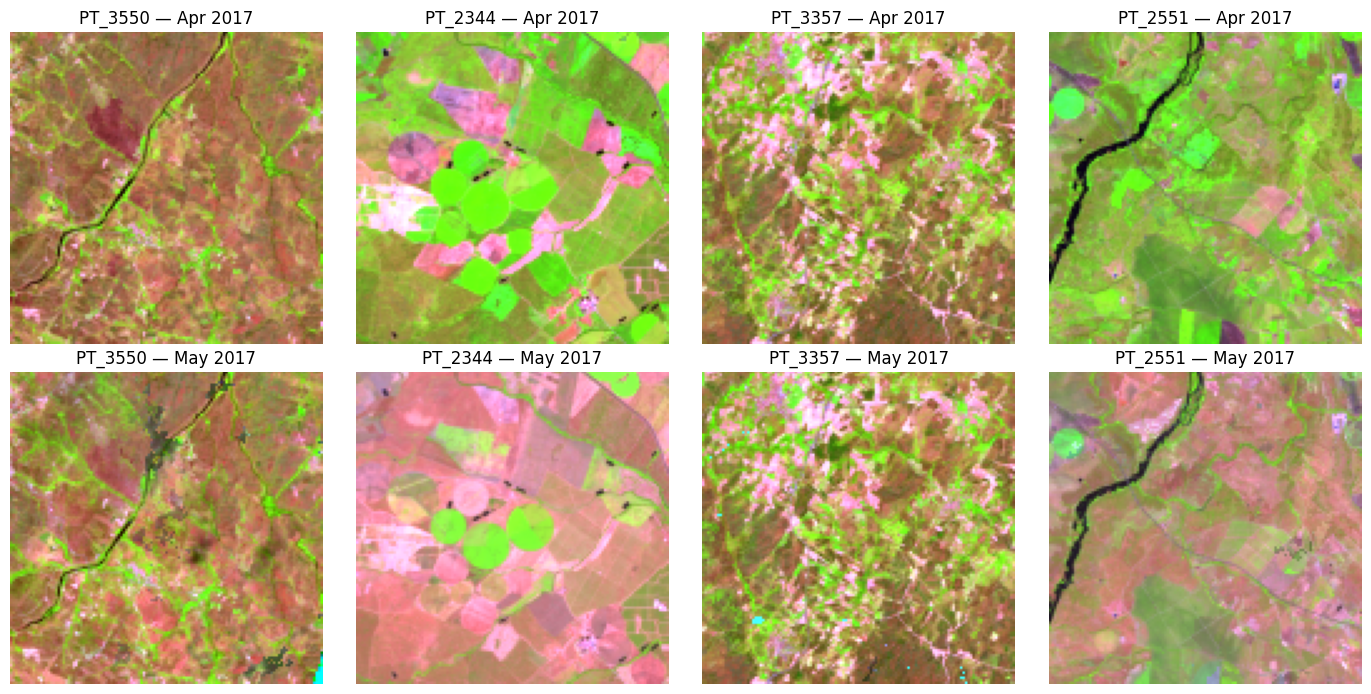

In [43]:
def false_color(patch):
    """SWIR (B11) → red, NIR (B8) → green, red (B4) → blue, with a fixed stretch."""
    b4, b8, b11 = patch.astype(float)
    rgb = np.stack([b11 / 4000, b8 / 4500, b4 / 2500], axis=-1)
    return np.clip(rgb, 0, 1)               


april = np.load(PATCH_DIR / "patches_2017_04.npy", mmap_mode="r")
may = np.load(PATCH_DIR / "patches_2017_05.npy", mmap_mode="r")

rng = np.random.default_rng(7)
land_cells = np.flatnonzero(grid["land_fraction"].values > 0.9)
sample = rng.choice(land_cells, size=4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for j, i in enumerate(sample):
    axes[0, j].imshow(false_color(april[i]))
    axes[0, j].set_title(f"{patch_index.loc[i, 'cell_id']} — Apr 2017")
    axes[1, j].imshow(false_color(may[i]))
    axes[1, j].set_title(f"{patch_index.loc[i, 'cell_id']} — May 2017")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Linking weekly observations to images

Each weekly observation `(cell_id, reference_date)` is linked to the composite of the
**month before the reference month**, from the same year (e.g. a reference Monday in
August uses the July composite). Because the composite ends on the last day of the
previous month, the image always predates the reference Monday, so no future information
is used.

The resulting table maps every row of the modelling dataset to a monthly patch file and a
patch index, and is the input of the CNN data loader in Notebook 06.

In [17]:
model_data = pd.read_parquet(
    PROCESSED_DIR / "model_dataset_full.parquet",
    columns=["cell_id", "reference_date"],
)

image_link = model_data.copy()
image_link["image_year"] = image_link["reference_date"].dt.year
image_link["image_month"] = image_link["reference_date"].dt.month - 1

image_link = image_link.merge(
    patch_index, on="cell_id", how="left", validate="many_to_one"
)

# Image age: days between the end of the composite month and the reference Monday
month_end = (
    pd.to_datetime(dict(year=image_link["image_year"],
                        month=image_link["image_month"], day=1))
    + pd.offsets.MonthEnd(0)
)
image_link["image_age_days"] = (image_link["reference_date"] - month_end).dt.days

# Checks
assert len(image_link) == 875_238
assert image_link["image_month"].between(4, 9).all()
assert image_link["patch_index"].notna().all()
assert (image_link["image_age_days"] > 0).all()   # composite always ends before the Monday

needed = image_link[["image_year", "image_month"]].drop_duplicates()
missing = [
    (y, m) for y, m in needed.itertuples(index=False)
    if not (PATCH_DIR / f"patches_{y}_{m:02d}.npy").exists()
]
print("Composites referenced:", len(needed), "| missing files:", missing)
print(image_link["image_age_days"].describe().round(1))

image_link.to_parquet(PROCESSED_DIR / "cnn_image_link.parquet", index=False)
print("Saved.")

Composites referenced: 54 | missing files: []
count    875238.0
mean         15.4
std           8.7
min           1.0
25%           8.0
50%          15.0
75%          23.0
max          31.0
Name: image_age_days, dtype: float64
Saved.


All 875,238 weekly observations are linked to one of the 54 monthly composites, and every
referenced file exists. The composite always ends before the reference Monday: the
time between the end of the composite month and the reference date ranges from 1 to 31
days (median 15). Since each composite is a median over its whole month, the effective age
of the image is about two weeks more.

## 5. Conversion to uint8

The uint16 patches total ≈19 GB. To stay well within the free Kaggle storage limits, they
are converted to **uint8** (≈9.6 GB), the standard format for images used with pre-trained
CNNs.

Each band is scaled with its own range: the upper bound is the **99.9th percentile** of
that band over pixels inside Portugal, estimated on a random sample of patches from all
years and months. Valid pixels are mapped to **1–255**, and **0 is reserved for pixels
outside Portugal or without data**, so a very dark real pixel (e.g. water) is never
confused with an empty one. Values above the upper bound (rare bright artefacts) are
clipped.

The scaling parameters are saved with the data so the transformation is documented and
reproducible.

In [18]:
import json

rng = np.random.default_rng(42)
patch_files = sorted(PATCH_DIR.glob("patches_*.npy"))
assert len(patch_files) == 54

samples = [[], [], []]

for npy in rng.choice(patch_files, size=12, replace=False):
    patches = np.load(npy, mmap_mode="r")
    for i in rng.choice(len(patches), size=100, replace=False):
        patch = np.asarray(patches[i])
        valid = patch.sum(axis=0) > 0
        for b in range(3):
            samples[b].append(patch[b][valid])

band_max = [float(np.percentile(np.concatenate(s), 99.9)) for s in samples]

scaling = {"bands": BANDS, "upper_bound_p99_9": band_max, "valid_range": [1, 255],
           "zero_means": "outside Portugal or no data"}

with open(PROCESSED_DIR / "uint8_scaling.json", "w") as f:
    json.dump(scaling, f, indent=2)

print(dict(zip(BANDS, [round(m) for m in band_max])))

{'B4': 3852, 'B8': 5430, 'B11': 5578}


In [19]:
U8_DIR = PROCESSED_DIR / "monthly_patches_uint8"
U8_DIR.mkdir(parents=True, exist_ok=True)

band_max_arr = np.array(band_max, dtype=np.float32).reshape(1, 3, 1, 1)

for npy in patch_files:
    out_path = U8_DIR / npy.name
    if out_path.exists():
        continue

    patches = np.load(npy).astype(np.float32)
    valid = patches.sum(axis=1, keepdims=True) > 0

    scaled = 1 + np.round(np.clip(patches / band_max_arr, 0, 1) * 254)
    scaled = np.where(valid, scaled, 0).astype(np.uint8)

    np.save(out_path, scaled)
    print(f"{npy.name} converted")

total_gb = sum(f.stat().st_size for f in U8_DIR.glob("*.npy")) / 1e9
print(f"Total uint8 size: {total_gb:.1f} GB")

patches_2017_04.npy converted
patches_2017_05.npy converted
patches_2017_06.npy converted
patches_2017_07.npy converted
patches_2017_08.npy converted
patches_2017_09.npy converted
patches_2018_04.npy converted
patches_2018_05.npy converted
patches_2018_06.npy converted
patches_2018_07.npy converted
patches_2018_08.npy converted
patches_2018_09.npy converted
patches_2019_04.npy converted
patches_2019_05.npy converted
patches_2019_06.npy converted
patches_2019_07.npy converted
patches_2019_08.npy converted
patches_2019_09.npy converted
patches_2020_04.npy converted
patches_2020_05.npy converted
patches_2020_06.npy converted
patches_2020_07.npy converted
patches_2020_08.npy converted
patches_2020_09.npy converted
patches_2021_04.npy converted
patches_2021_05.npy converted
patches_2021_06.npy converted
patches_2021_07.npy converted
patches_2021_08.npy converted
patches_2021_09.npy converted
patches_2022_04.npy converted
patches_2022_05.npy converted
patches_2022_06.npy converted
patches_20

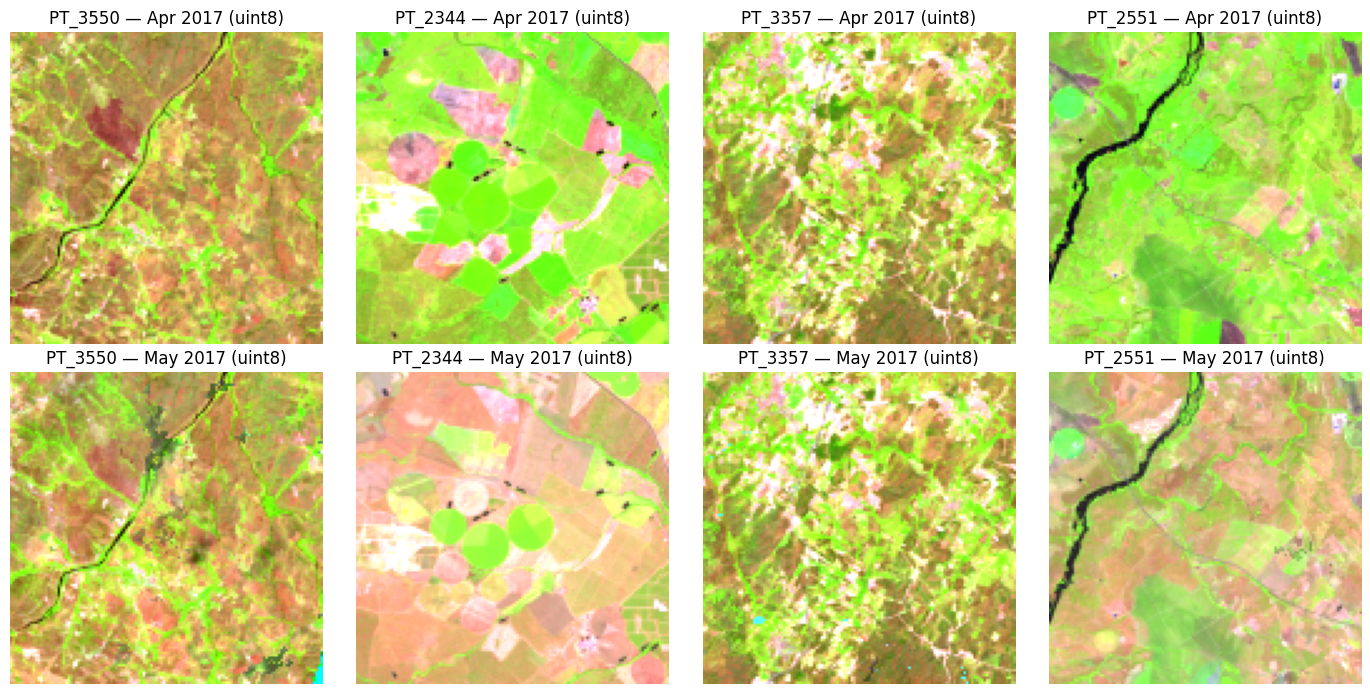

In [21]:
def false_color_u8(patch):
    b4, b8, b11 = patch.astype(float) / 255
    return np.clip(np.stack([b11, b8, b4], axis=-1) * 1.6, 0, 1)


april_u8 = np.load(U8_DIR / "patches_2017_04.npy", mmap_mode="r")
may_u8 = np.load(U8_DIR / "patches_2017_05.npy", mmap_mode="r")

rng = np.random.default_rng(7)
land_cells = np.flatnonzero(grid["land_fraction"].values > 0.9)
sample = rng.choice(land_cells, size=4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for j, i in enumerate(sample):
    axes[0, j].imshow(false_color_u8(april_u8[i]))
    axes[0, j].set_title(f"{patch_index.loc[i, 'cell_id']} — Apr 2017 (uint8)")
    axes[1, j].imshow(false_color_u8(may_u8[i]))
    axes[1, j].set_title(f"{patch_index.loc[i, 'cell_id']} — May 2017 (uint8)")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

The per-band upper bounds (99.9th percentile) are **B4 = 3,852**, **B8 = 5,430** and
**B11 = 5,578**. Each of the 254 valid levels therefore corresponds to about 15–22
reflectance units (≈ 0.15–0.22% reflectance), a loss of precision that is negligible for
a CNN. The uint8 patches total **9.7 GB**.

The visual check confirms that landscape structure and the seasonal drying between April
and May are preserved, and that dark real surfaces such as rivers remain distinct from
the empty value 0. The uint16 patches were deleted after this verification.

In [24]:
import shutil
import json

KAGGLE_USERNAME = "danielalux"
UPLOAD_DIR = Path("../data/kaggle_upload")
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

# Patches: moved (not copied) to avoid duplicating 9.7 GB on disk
for npy in sorted(U8_DIR.glob("patches_*.npy")):
    shutil.move(str(npy), UPLOAD_DIR / npy.name)

# Tables and scaling parameters: copied
for name in [
    "cnn_image_link.parquet",
    "monthly_patch_index.parquet",
    "model_dataset_full.parquet",
    "uint8_scaling.json",
]:
    shutil.copy2(PROCESSED_DIR / name, UPLOAD_DIR / name)

metadata = {
    "title": "Wildfire Risk Portugal CNN Inputs",
    "id": f"{KAGGLE_USERNAME}/wildfire-risk-portugal-cnn",
    "licenses": [{"name": "other"}],
}
with open(UPLOAD_DIR / "dataset-metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

files = sorted(p.name for p in UPLOAD_DIR.iterdir())
print(len(files), "files")
print(f"{sum(p.stat().st_size for p in UPLOAD_DIR.iterdir()) / 1e9:.1f} GB")

59 files
9.8 GB


In [ ]:
upload_path = UPLOAD_DIR.resolve()
print(upload_path)

!kaggle datasets create -p "{upload_path}"

## 6. Upload to Kaggle

The CNN is trained on Kaggle's free GPU tier. The following files were uploaded as a
private Kaggle dataset (`wildfire-risk-portugal-cnn`, ≈ 9.8 GB) using the official Kaggle
command-line tool:

| File | Content |
|---|---|
| `patches_YYYY_MM.npy` (54 files) | uint8 monthly patches, 3,822 × 3 × 125 × 125 |
| `cnn_image_link.parquet` | links each weekly observation to its monthly patch |
| `monthly_patch_index.parquet` | maps each patch index to its `cell_id` |
| `model_dataset_full.parquet` | target, weather, context and Sentinel features |
| `uint8_scaling.json` | per-band scaling parameters of the uint8 conversion |

All files are stored at the top level of the dataset, without sub-folders. The command
must receive an absolute path: relative paths containing `..` fail on Windows because the
tool uses them to build temporary file names.